In [1]:
#!pip install -r requirements.txt

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data/restructured.csv")

In [4]:
# combine title and story into one column
df['combined'] = '[TITLE] ' + df['story_title'] + ' [TEXT] ' + df['story_text']

In [5]:
# remove rows where there is no center (group for roundup_title and check if there is a center)

# Count how many bias labels exist per roundup
grouped = df.groupby('roundup_title')['bias_label'].nunique()

# Filter only roundups that contain all 3 labels
valid_titles = grouped[grouped == 3].index

# Keep only rows with those titles
df = df[df['roundup_title'].isin(valid_titles)].copy()

In [6]:
# check balance of the dataset
df['bias_label'].value_counts()

bias_label
center    7564
left      7564
right     7563
Name: count, dtype: int64

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['bias_label'])  # center=0, left=1, right=2

# Split into train/val/test
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_enc'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label_enc'], random_state=42)

In [8]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[['combined', 'label_enc']])
val_ds = Dataset.from_pandas(val_df[['combined', 'label_enc']])
test_ds = Dataset.from_pandas(test_df[['combined', 'label_enc']])

c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)


c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Besitzer\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https:

In [10]:
def tokenize(example):
    return tokenizer(example["combined"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label_enc", "labels")
val_ds = val_ds.rename_column("label_enc", "labels")
test_ds = test_ds.rename_column("label_enc", "labels")

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")


Map:   0%|          | 0/14521 [00:00<?, ? examples/s]

Map: 100%|██████████| 4539/4539 [00:00<00:00, 9778.82 examples/s]


In [11]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {"accuracy": (preds == p.label_ids).mean().item()}

training_args = TrainingArguments(
    output_dir="./bert-output",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


  0%|          | 0/2724 [00:00<?, ?it/s]c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 18%|█▊        | 500/2724 [27:27<1:59:59,  3.24s/it]

{'loss': 1.0947, 'grad_norm': 1.2828270196914673, 'learning_rate': 4.082232011747431e-05, 'epoch': 0.55}


                                                    
 33%|███▎      | 908/2724 [52:56<1:26:19,  2.85s/it]

{'eval_loss': 1.022304654121399, 'eval_accuracy': 0.4728724869182043, 'eval_runtime': 205.3786, 'eval_samples_per_second': 17.68, 'eval_steps_per_second': 0.555, 'epoch': 1.0}


c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 37%|███▋      | 1000/2724 [58:03<1:33:41,  3.26s/it]

...

                                                     
100%|██████████| 2724/2724 [2:52:58<00:00,  3.44s/it]

{'eval_loss': 1.050435185432434, 'eval_accuracy': 0.5414486367391903, 'eval_runtime': 221.0418, 'eval_samples_per_second': 16.427, 'eval_steps_per_second': 0.516, 'epoch': 3.0}


100%|██████████| 2724/2724 [2:52:59<00:00,  3.81s/it]

{'train_runtime': 10379.7268, 'train_samples_per_second': 4.197, 'train_steps_per_second': 0.262, 'train_loss': 0.913380431008584, 'epoch': 3.0}


TrainOutput(global_step=2724, training_loss=0.913380431008584, metrics={'train_runtime': 10379.7268, 'train_samples_per_second': 4.197, 'train_steps_per_second': 0.262, 'total_flos': 1442695049872128.0, 'train_loss': 0.913380431008584, 'epoch': 3.0})

In [14]:
# save the model 
trainer.save_model("final_bert")
# save the tokenizer
tokenizer.save_pretrained("final_bert")
# save the label encoder
import joblib
joblib.dump(le, "final_bert/label_encoder.pkl")

['final_bert/label_encoder.pkl']

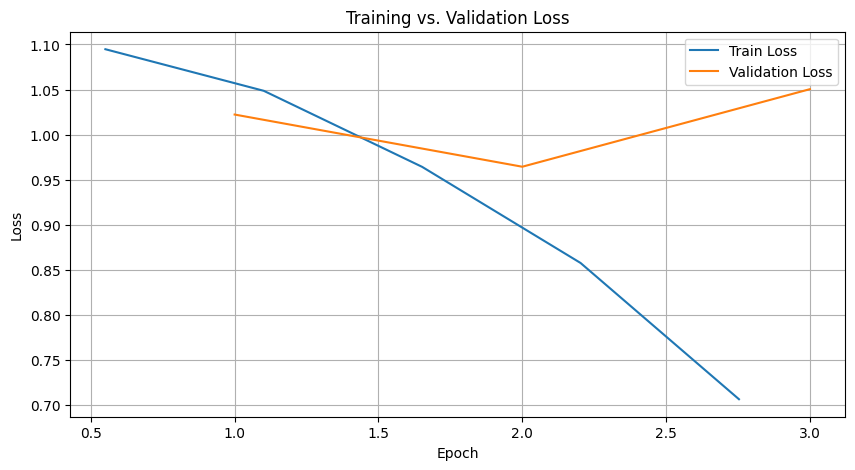

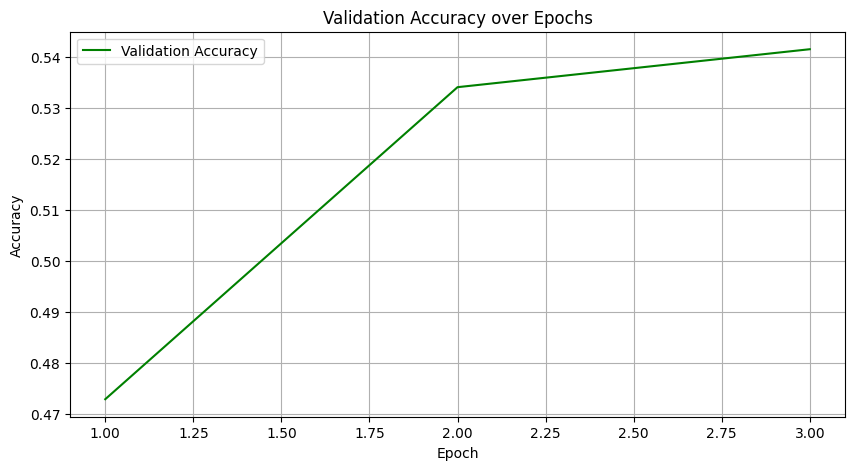

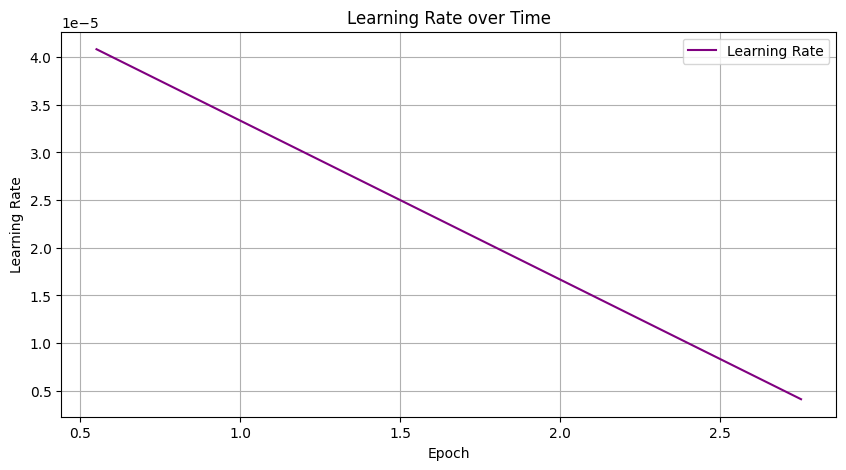

In [18]:
import matplotlib.pyplot as plt

# Extract log history
log_history = trainer.state.log_history

# Loss
train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
epochs_train = [x['epoch'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
epochs_eval = [x['epoch'] for x in log_history if 'eval_loss' in x]

# Accuracy
eval_accuracy = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
epochs_acc = [x['epoch'] for x in log_history if 'eval_accuracy' in x]

# Learning rate
learning_rates = [x['learning_rate'] for x in log_history if 'learning_rate' in x]
epochs_lr = [x['epoch'] for x in log_history if 'learning_rate' in x]

# --- Plot 1: Loss ---
plt.figure(figsize=(10, 5))
plt.plot(epochs_train, train_loss, label="Train Loss")
plt.plot(epochs_eval, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: Accuracy ---
plt.figure(figsize=(10, 5))
plt.plot(epochs_acc, eval_accuracy, label="Validation Accuracy", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 3: Learning Rate ---
plt.figure(figsize=(10, 5))
plt.plot(epochs_lr, learning_rates, label="Learning Rate", color='purple')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate over Time")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
preds = trainer.predict(test_ds)
y_pred = preds.predictions.argmax(-1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred, target_names=le.classes_))


c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 142/142 [04:33<00:00,  1.93s/it]

              precision    recall  f1-score   support

      center       0.55      0.57      0.56      1513
        left       0.51      0.58      0.54      1513
       right       0.59      0.48      0.53      1513

    accuracy                           0.54      4539
   macro avg       0.55      0.54      0.54      4539
weighted avg       0.55      0.54      0.54      4539



In [20]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import classification_report
from datasets import Dataset
import numpy as np
import joblib

# === 1. Load model, tokenizer, label encoder ===
model = AutoModelForSequenceClassification.from_pretrained("final_bert")
tokenizer = AutoTokenizer.from_pretrained("final_bert")
le = joblib.load("final_bert/label_encoder.pkl")



# === 3. New Trainer instance for prediction ===
trainer = Trainer(model=model)

# === 4. Predict ===
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# === 5. Decode numeric labels to class names ===
decoded_pred = le.inverse_transform(y_pred)
decoded_true = le.inverse_transform(y_true)

# === 6. Evaluation report ===
print(classification_report(decoded_true, decoded_pred, target_names=le.classes_))


c:\Users\Besitzer\OneDrive\Dokumente\CBS_Copenhagen\Semester\SS2025\NLP & Text Analytics\Final Exam\NLP_Final\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 568/568 [08:13<00:00,  1.15it/s]

              precision    recall  f1-score   support

      center       0.55      0.57      0.56      1513
        left       0.51      0.58      0.54      1513
       right       0.59      0.48      0.53      1513

    accuracy                           0.54      4539
   macro avg       0.55      0.54      0.54      4539
weighted avg       0.55      0.54      0.54      4539

